# Congestion Pricing and NYC Drivers

On 5 January 2025 New York started charging a toll to enter Manhattan below 60th Street. This notebook measures how the toll changed yellow taxi and rideshare (Uber/Lyft) trips and driver earnings.

Run it from top to bottom. The functions it calls live in `scripts/`. Setup steps are in `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

from scripts import (clean, config, download, external, plots,
                     spark_io, zones)

# Uncomment for a 4-month test run instead of all 36 (see README)
# config.QUICK_RUN = True

# Every figure uses the shared style
plt.style.use(config.STYLE_FILE)

months = config.months_to_process()
print(f"QUICK_RUN = {config.QUICK_RUN}: {len(months)} months, "
      f"{months[0]} to {months[-1]}")

QUICK_RUN = False: 36 months, (2023, 1) to (2025, 12)


## 1. Download the data

Everything is saved to `data/raw/`. Each download is skipped if its file is already there, so running this section again is quick. The functions are in `scripts/download.py`.

### 1.1 TLC trip data

One parquet file per month for yellow taxis and High Volume FHV (Uber/Lyft), from the [TLC trip record page](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). The full run downloads 72 files (about 20 GB), four at a time. The table shows rows × columns of every raw file, read from the parquet metadata without loading the data.

HVFHV January to July 2023 each store the whole month in one row group (820–935 MB uncompressed). Spark can't split a row group, so reading several of these at once ran Spark out of memory. `split_large_row_groups` rewrites those files once into row groups of 1,048,576 rows, the size the TLC uses in later files. The rows, columns and types are unchanged: the function checks the row count and schema before replacing a file, and on July 2023 the column totals of `driver_pay`, `trip_miles` and `PULocationID` matched exactly. File sizes in the table are after the rewrite.

In [2]:
tlc_files = download.download_tlc(months)
download.split_large_row_groups(tlc_files)

# Rows x columns of every raw TLC file
tlc_shapes = download.parquet_shapes(tlc_files)
tlc_shapes["service"] = tlc_shapes["file"].str.split("_").str[0]

# Totals per service, for Table 1 in the report
tlc_shapes.groupby("service").agg(
    files=("file", "count"), rows=("rows", "sum"),
    min_columns=("columns", "min"), max_columns=("columns", "max"),
    size_gb=("size_mb", lambda mb: round(mb.sum() / 1000, 1)))

TLC: 72 files, 72 already downloaded, 0 to download


,files,rows,min_columns,max_columns,size_gb
service,,,,,
fhvhv,36,715550152,24,25,17.3
yellow,36,128202548,19,20,2.2


In [3]:
# Rows x columns of each monthly file. The column count changes when the
# TLC adds a column, such as cbd_congestion_fee in 2025.
tlc_shapes.set_index("file")[["rows", "columns", "size_mb"]]

,rows,columns,size_mb
file,,,
yellow_tripdata_2023-01.parquet,3066766,19,47.7
yellow_tripdata_2023-02.parquet,2913955,19,47.7
yellow_tripdata_2023-03.parquet,3403766,19,56.1
yellow_tripdata_2023-04.parquet,3288250,19,54.2
yellow_tripdata_2023-05.parquet,3513649,19,58.7
...,...,...,...
fhvhv_tripdata_2025-08.parquet,19271461,25,479.6
fhvhv_tripdata_2025-09.parquet,19434641,25,480.9
fhvhv_tripdata_2025-10.parquet,21308701,25,518.5


### 1.2 External datasets

Sources and notes are in `external_datasets.md`:

- **TLC taxi zone lookup and shapefile:** zone names, boroughs and shapes
- **MTA CBD taxi zones** ([data.ny.gov](https://data.ny.gov/d/yfdc-w5jh)): the 38 zones inside the tolled area
- **MTA CBD taxi/FHV speeds** ([data.ny.gov](https://data.ny.gov/d/6p29-6xqn)): monthly speeds, for one line of background
- **NOAA daily weather** for Central Park (station `USW00094728`), in metric units (mm, °C)
- **MTA subway hourly ridership** ([2023–2024](https://data.ny.gov/d/wujg-7c2s), [2025](https://data.ny.gov/d/5wq4-mkjj)): only the months in `months`

data.ny.gov returns only 1,000 rows per request by default, so the downloads set `$limit`, sort with `$order`, page with `$offset`, and check the row count against the server's own count.

The raw subway data is too big to download (about 25–45 million rows a year), so data.ny.gov groups it first: ridership is summed over payment method and fare class, leaving one row per station and hour. Grouping a whole month in one request takes minutes on their server, so it is requested one day at a time and saved one file per month. The full 36 months took 30 minutes.

In [4]:
external_files = download.download_external(months)

# Rows x columns of each raw external dataset (subway months added together)
download.external_shapes(external_files)

Taxi zones
MTA CBD taxi zones
MTA CBD speeds
NOAA weather
MTA subway ridership: 36 months


,dataset,files,rows,columns
0,lookup,1,265,4
1,cbd_zones,1,38,2
2,cbd_speeds,1,213,3
3,weather,1,1096,7
4,shapefile,1,263,7
5,subway,36,11217688,8


## 2. Prepare the external data

CBD zone labels, the buffer ring, subway ridership, weather and holidays. This comes before cleaning the taxi data, because the cleaning step needs the zone labels.

### 2.1 Zone labels

Every taxi zone gets one label (functions in `scripts/zones.py`):

- `cbd`: one of the 38 zones on the MTA's list of zones inside the congestion relief zone
- `ring`: outside the CBD, but touching it or within 1 km (3,281 ft) of it. The distance catches zones across the East River, such as Long Island City and DUMBO.
- `control`: every other zone

Distances are measured in the shapefile's own projection, EPSG:2263 (NY State Plane, in feet). In the current shapefile every zone ID from 1 to 263 has exactly one shape, so the old duplicates (56/57 and 103/104/105) are no longer a problem. Zones 264 and 265 have no shape and get no label.

In [5]:
zone_labels = zones.build_zone_labels()
print(f"Zone labels: {zone_labels.shape[0]} rows x {zone_labels.shape[1]} "
      f"columns, saved to {zones.LABELS_FILE.name}")
print(zone_labels["zone_group"].value_counts(dropna=False).to_string())

# The ring zones, nearest first
(zone_labels[zone_labels["zone_group"] == "ring"]
 .sort_values("distance_to_cbd_ft")
 [["LocationID", "Borough", "Zone", "distance_to_cbd_ft"]])

Zone labels: 265 rows x 7 columns, saved to zone_labels.csv
zone_group
control    206
cbd         38
ring        19
NaN          2


,LocationID,Borough,Zone,distance_to_cbd_ft
140,141,Manhattan,Lenox Hill West,0.0
42,43,Manhattan,Central Park,0.0
236,237,Manhattan,Upper East Side South,0.0
142,143,Manhattan,Lincoln Square West,0.0
141,142,Manhattan,Lincoln Square East,0.0
139,140,Manhattan,Lenox Hill East,0.0
201,202,Manhattan,Roosevelt Island,908.0
144,145,Queens,Long Island City/Hunters Point,1334.0
33,34,Brooklyn,Brooklyn Navy Yard,1374.0
32,33,Brooklyn,Brooklyn Heights,1416.0


In [6]:
# Zone IDs that share a name. The check inside shared_names()
# also confirms that no two zones share a shape, so maps and
# joins keyed on LocationID cannot double-count them.
zones.shared_names()

,LocationID,zone,borough,area_sq_mi
0,56,Corona,Queens,0.655
1,57,Corona,Queens,0.065
2,103,Governor's Island/Ellis Island/Liberty Island,Manhattan,0.023
3,104,Governor's Island/Ellis Island/Liberty Island,Manhattan,0.043
4,105,Governor's Island/Ellis Island/Liberty Island,Manhattan,0.277


### 2.2 Subway ridership by zone

Question 4 asks whether the car trips lost to the toll moved to the subway, so ridership has to be measured in the same places and hours as the trips (`scripts/external.py`).

- Each station complex is placed in the taxi zone its coordinates fall in. Every complex lands inside a zone, so none needs the nearest-zone fallback.
- In 2023–2024 a complex can have several coordinate pairs, one per platform, so the same complex and hour appears on more than one row (Section 1.2). Ridership is summed over the pairs and each complex keeps its busiest pair as its location, which makes the two source datasets comparable.
- Riders and transfers are then totalled per zone, date and time band, using the same bands as the trip data.

Checked: the monthly totals of the zone table match the raw files exactly in all 36 months.

In [7]:
stations = external.station_zones()
print(f"{len(stations)} station complexes, "
      f"{stations['LocationID'].nunique()} zones with a station")
print(stations["matched_by"].value_counts().to_string())

subway = external.subway_by_zone()
print(f"Subway by zone: {subway.shape[0]:,} rows x "
      f"{subway.shape[1]} columns, saved to "
      f"{external.SUBWAY_ZONE_FILE.name}")

# Riders per year by zone group (millions)
groups = zone_labels.set_index("LocationID")["zone_group"]
(subway.assign(zone_group=subway["LocationID"].map(groups),
               year=subway["date"].dt.year)
 .groupby(["year", "zone_group"])["subway_riders"].sum()
 .unstack("zone_group")[["cbd", "ring", "control"]]
 / 1e6).round(1)

425 station complexes, 153 zones with a station
matched_by
inside    425


Subway by zone: 663,669 rows x 5 columns, saved to subway_by_zone.parquet


zone_group,cbd,ring,control
year,,,
2023,442.7,135.2,580.4
2024,473.3,142.0,590.8
2025,508.2,151.0,639.3


### 2.3 Weather and public holidays

Daily weather comes from the NOAA Central Park station. It was requested in metric units (mm and °C), so nothing needs converting. A missing snow depth means no snow was lying and becomes 0; no other value is missing.

Public holidays are the US federal holidays of 2023–2025, plus the weekday a holiday was observed on when it fell at a weekend, because that is the day people stay off work. They are listed in `external.HOLIDAYS` rather than taken from a package, so the pinned requirements don't grow.

In [8]:
weather = external.load_weather()
print(f"Weather: {weather.shape[0]:,} rows x "
      f"{weather.shape[1]} columns, "
      f"{weather['date'].min():%Y-%m-%d} to "
      f"{weather['date'].max():%Y-%m-%d}")
print(f"Public holidays: {len(external.HOLIDAYS)} dates")
weather.drop(columns="date").describe().round(1)

Weather: 1,096 rows x 6 columns, 2023-01-01 to 2025-12-31
Public holidays: 35 dates


,rain_mm,snow_mm,snow_depth_mm,temp_max_c,temp_min_c
count,1096.0,1096.0,1096.0,1096.0,1096.0
mean,3.4,0.7,1.6,17.9,10.1
std,9.6,5.7,8.6,9.5,8.5
min,0.0,0.0,0.0,-7.1,-16.0
25%,0.0,0.0,0.0,10.0,3.3
50%,0.0,0.0,0.0,17.8,10.0
75%,1.4,0.0,0.0,26.1,17.8
max,139.2,81.0,102.0,37.2,27.2


## 3. Clean the taxi data

The trips are checked, cleaned and summarised with PySpark (functions in `scripts/clean.py`). Every check and outlier cut-off uses the **full** data, not a sample.

### 3.1 Read the raw files

The monthly files don't share one schema: January 2023 stores some IDs as int64 (int32 afterwards), the yellow column `airport_fee` is spelled `Airport_fee` from February 2023, and `cbd_congestion_fee` only exists from 2025. `scripts/spark_io.py` reads each month, keeps only the columns we need, casts them to one schema and stacks the months.

Kept columns: 17 for yellow and 14 for High Volume FHV (listed in `spark_io.YELLOW_COLUMNS` and `FHVHV_COLUMNS`), plus `file_month` (the month of the source file). Tips are left out on purpose (Section 5 of the plan), and so are columns the analysis never uses, such as `store_and_fwd_flag` and the HVFHV base numbers.

In [9]:
spark = spark_io.get_spark()
spark.sparkContext.setLogLevel("ERROR")

# Raw trips with the kept columns, plus trip_seconds, trip_hours, speed_mph
raw = {service: clean.add_trip_time(
           spark_io.read_service(spark, service, months), service)
       for service in config.SERVICES}

# Raw rows x columns (the column count differs between years)
raw_shapes = {}
for service in config.SERVICES:
    files = tlc_shapes[tlc_shapes["service"] == service]
    low, high = files["columns"].min(), files["columns"].max()
    raw_shapes[service] = (int(files["rows"].sum()),
                           str(low) if low == high else f"{low}-{high}")
    print(f"{service}: {raw_shapes[service][0]:,} rows x "
          f"{raw_shapes[service][1]} raw columns, "
          f"{len(spark_io.COLUMNS[service])} kept")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 00:01:43 WARN Utils: Your hostname, Alinas-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.247 instead (on interface en0)
26/09/18 00:01:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/18 00:01:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/18 00:01:44 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


yellow: 128,202,548 rows x 19-20 raw columns, 17 kept
fhvhv: 715,550,152 rows x 24-25 raw columns, 14 kept


### 3.2 Nulls

Nulls in every kept column, counted on the full data by month, vendor and (for yellow) payment type. The tables below add the months up by year.

In [10]:
nulls = {service: clean.null_counts(raw[service], service)
         for service in config.SERVICES}

# Yellow: nulls by year, vendor and payment type
clean.nulls_by_year(nulls["yellow"], ["VendorID", "payment_type"])

rows  passenger_count  RatecodeID  \
year VendorID payment_type                                          
2023 1        0               508731           508731      508731   
              1              7727736                0           0   
              2              1634375                0           0   
              3               116785                0           0   
              4                50085                0           0   
              5                    2                0           0   
     2        0               791957           791957      791957   
              1             22129196                0           0   
              2              4770684                0           0   
              3               124077                0           0   
              4               447930                0           0   
     6        0                 8668             8668        8668   
2024 1        0               864554           864554      864554   
              1              7380743                0           0   
              2              1298031                0           0   
              3               111315                0           0   
              4                61271                0           0   
              5                    4                0           0   
     2        0              3224609          3224609     3224609   
              1             23071224                0           0   
              2              4242023                0           0   
              3               180424                0           0   
              4               733223                0           0   
     6        0                 2069             2069        2069   
     7        1                  192                0           0   
              2                   34                0           0   
              3                    4                0           0   
2025 1        0              1579612          1579612     1579612   
              1              6897876                0           0   
              2               936578                0           0   
              3               104331                0           0   
              4                68473                0           0   
              5                    3                0           0   
     2        0             10008300         10008300    10008300   
              1             23695509                0           0   
              2              3649535                0           0   
              3               199259                0           0   
              4              1023243                0           0   
     6        0                23982            23982       23982   
     7        1               460615                0           0   
              2                68232                0           0   
              3                 4557                0           0   
              4                 2497                0           0   

                            congestion_surcharge  airport_fee  \
year VendorID payment_type                                      
2023 1        0                           508731       508731   
              1                                0            0   
              2                                0            0   
              3                                0            0   
              4                                0            0   
              5                                0            0   
     2        0                           791957       791957   
              1                                0            0   
              2                                0            0   
              3                                0            0   
              4                                0            0   
     6        0                             8668         8668   
2024 1        0 

In [11]:
# High Volume FHV: nulls by year and company (HV0003 = Uber, HV0005 = Lyft)
clean.nulls_by_year(nulls["fhvhv"], ["hvfhs_license_num"])

rows  cbd_congestion_fee  null_pct
year hvfhs_license_num                                         
2023 HV0003             167127330           167127330     100.0
     HV0005              65362690            65362690     100.0
2024 HV0003             179125798           179125798     100.0
     HV0005              60344650            60344650     100.0
2025 HV0003             175989546                   0       0.0
     HV0005              67600138                   0       0.0

**What the null counts show:**

- **Yellow:** only four columns ever have nulls: `passenger_count`, `RatecodeID`, `congestion_surcharge` and `airport_fee`. In every year and for every vendor they are null on exactly the `payment_type` 0 (Flex Fare) rows and on no others. `cbd_congestion_fee` is null on every 2023–2024 row, because the column only starts in 2025, and never null in 2025.
- **High Volume FHV:** no nulls in any kept column, apart from `cbd_congestion_fee` before 2025.

**Decisions:**

- `cbd_congestion_fee` before 2025: leave null. It didn't exist, and trips are put inside or outside the zone with the MTA zone list for every year, not with this column.
- The four Flex Fare columns: leave null, and keep the rows (next section). The fee columns are not filled with 0, because `total_amount` still includes the city and MTA charges on these trips; they just aren't itemised. Revenue doesn't use these columns, and `passenger_count` and `RatecodeID` aren't used in the analysis.
- Nothing is imputed or dropped because of nulls.

### 3.3 Yellow Flex Fare trips

The data dictionary lists `payment_type` 0 as a Flex Fare trip, a fixed price agreed upfront. The check below confirms, month by month, that the rows with all four columns null are exactly the Flex Fare trips.

In [12]:
flex = clean.flex_fare_check(raw["yellow"])

# Every null row is a Flex Fare trip, and every Flex Fare trip has all
# four nulls, with no rows that have only some of the four
assert (flex["both"] == flex["flex_fare"]).all()
assert (flex["both"] == flex["all_four_null"]).all()
assert (flex["some_null"] == 0).all()

flex_by_year = (flex.assign(year=pd.to_datetime(flex["file_month"]).dt.year)
                .groupby("year")[["rows", "flex_fare"]].sum())
flex_by_year["flex_pct"] = (flex_by_year["flex_fare"] / flex_by_year["rows"]
                            * 100).round(1)
flex_by_year

,rows,flex_fare,flex_pct
year,,,
2023,38310226,1309356,3.4
2024,41169720,4091232,9.9
2025,48722602,11611894,23.8


The null rows are exactly the Flex Fare trips in all 36 months, and Flex Fare's share of yellow trips grows from 3.4% in 2023 to 9.9% in 2024 and 23.8% in 2025. **The rows are kept:** they are real trips, and dropping a group that grows this fast would make yellow trips look like they fell after the toll. Section 3.8 checks that the share grows at a similar rate for trips inside and outside the zone.

**A recording problem in Flex Fare fares:** from January to November 2025, Vendor 2 (Curb) recorded a negative `fare_amount` on many of its Flex Fare trips (often exactly -$4.75), with a small positive `total_amount`, such as $1.00 for a 2.4-mile trip. The table below counts them. These rows are not reversals: in May 2025 none of them had a matching positive row, while about 89% of the negative cash, no-charge and dispute rows did. The distances and times look normal, and the problem stops in December 2025. So these trips are **kept for trip counts, but their revenue is set to unknown** (Section 3.7).

In [13]:
# Zero and negative fares by year, vendor and payment type
fares = clean.fare_signs(raw["yellow"])
fares[fares["negative"] + fares["zero"] > 1000]

,year,VendorID,payment_type,rows,negative,zero,negative_pct
1,2023,1,1,7727736,5,1154,0.00
2,2023,1,2,1634375,0,1386,0.00
3,2023,1,3,116785,0,2249,0.00
4,2023,1,4,50085,0,2305,0.00
6,2023,2,0,791957,6773,122,0.86
7,2023,2,1,22129196,230,1402,0.00
8,2023,2,2,4770684,88635,3944,1.86
9,2023,2,3,124077,62054,26,50.01
10,2023,2,4,447930,223947,70,50.00
14,2024,1,2,1298031,0,1037,0.00


### 3.4 Yellow `extra`

Revenue for yellow taxis is `fare_amount` plus the part of `extra` that goes to the driver. The TLC fare rules have three such surcharges: $1 overnight (8pm–6am), $2.50 on weekday rush hours (4–8pm) and $5 on LaGuardia trips and JFK flat-fare trips. In May 2024, 75% of Vendor 2 trips with `extra` = $5 went to or from LaGuardia and 20% were JFK flat fares. So the driver's part of `extra` should be 0, 1, 2.50, 5, 6 or 7.50. The current data dictionary only calls `extra` "miscellaneous extras and surcharges", so we check its values by vendor.

In [14]:
extra = clean.extra_values(raw["yellow"])
extra["year"] = pd.to_datetime(extra["file_month"]).dt.year

# Most common extra values: share of each vendor-year's trips, in %
extra_shares = (extra.groupby(["VendorID", "year", "extra"])["count"].sum()
                / extra.groupby(["VendorID", "year"])["count"].sum() * 100)
(extra_shares[extra_shares > 1].round(1).rename("pct")
 .reset_index().pivot(index=["VendorID", "extra"], columns="year",
                      values="pct").fillna(0))

year             2023   2024   2025
VendorID extra                     
1        0.00     8.3   14.5   25.0
         2.50    45.3   42.2    9.6
         3.25     0.0    0.0   27.9
         3.50    21.3   20.3    2.2
         4.25     1.3    1.3   15.3
         5.00    16.1   15.2    3.7
         5.75     0.0    0.0   10.2
         9.25     1.3    1.6    0.0
         10.00    0.0    0.0    1.0
2        0.00    51.6   55.5   63.2
         1.00    25.4   22.7   18.4
         2.50    16.7   15.6   13.2
         5.00     3.8    3.4    2.7
         6.00     1.1    1.0    0.0
6        0.00   100.0   80.0  100.0
         0.50     0.0   20.0    0.0
7        0.00     0.0  100.0  100.0

**What the table shows:**

- **Vendor 2 (Curb)**, about three quarters of yellow trips: `extra` is almost always 0, 1, 2.50, 5, 6 or 7.50, so it holds only the driver surcharges. The small negative values (-1, -2.50) belong to reversal rows, which are removed with the negative fares.
- **Vendor 1 (Creative Mobile Technologies)**: the most common values are 2.50, 3.50 and 5.00 in 2023–2024, and 3.25, 4.25 and 5.75 in 2025. These are the driver surcharges plus the $2.50 congestion surcharge, the $1.75 airport fee and, from 2025, the $0.75 CBD fee. Vendor 1 puts those city and MTA charges into `extra` **as well as** in their own columns.

**Rule:** for Vendor 1, subtract `congestion_surcharge`, `airport_fee` and `cbd_congestion_fee` from `extra`. If that doesn't leave a valid driver surcharge, try again without subtracting the CBD fee, because on some 2025 rows Vendor 1 left the CBD fee out of `extra`. Other vendors' `extra` is used as it is. If no valid surcharge is found, the trip's revenue is unknown (null) but the trip is kept. The next cell counts how many trips the rule matches, and the one after checks that the surcharges it finds happen at the right hours.

In [15]:
# How many trips get a valid driver surcharge, by vendor and year
clean.extra_rule_coverage(raw["yellow"])

,VendorID,year,rows,matched,matched_share
0,1,2023,10037714,10022656,0.998500
1,1,2024,9715918,9699529,0.998313
2,1,2025,9586873,9573071,0.998560
3,2,2023,28263844,28069946,0.993140
4,2,2024,31451503,31145278,0.990264
5,2,2025,38575846,38155557,0.989105
6,6,2023,8668,8668,1.000000
7,6,2024,2069,1656,0.800387
8,6,2025,23982,23982,1.000000
9,7,2024,230,230,1.000000


In [16]:
# Weekday trips: share of each hour's trips with each driver surcharge (%).
# $1 should appear from 8pm to 6am and $2.50 from 4pm to 8pm.
clean.driver_extra_by_hour(raw["yellow"]).loc[[0.0, 1.0, 2.5, 5.0]]

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
driver_extra,,,,,,,,,,,,,,,,,,,,,
0.0,24.5,23.5,23.7,29.6,46.0,44.1,94.6,96.4,96.2,94.7,...,94.0,93.1,17.3,15.1,15.9,15.2,16.5,17.8,20.9,23.7
1.0,69.9,73.6,74.4,67.4,46.7,49.4,2.0,0.0,0.0,0.0,...,0.1,0.1,0.1,0.1,0.1,1.5,75.8,78.9,75.8,71.6
2.5,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,...,0.1,1.6,73.4,77.9,78.4,77.1,4.1,0.0,0.0,0.0
5.0,0.1,0.1,0.1,0.2,0.5,0.5,3.3,3.5,3.8,5.2,...,5.8,5.1,5.0,3.4,2.7,3.0,0.1,0.1,0.1,0.1


The rule finds a valid driver surcharge on over 99.8% of Vendor 1 trips in every year, including 2025 after the CBD fallback, and on about 99% of Vendor 2 trips. Most of the rest are negative reversal rows, which are removed anyway. The hourly table confirms the surcharges: on weekdays, $1 appears on most trips from 8pm to 6am and on almost none during the day, and $2.50 on most trips from 4pm to 8pm.

### 3.5 Distributions and outlier cut-offs

Quantiles of trip length (minutes), distance (miles), average speed (mph) and money (`fare_amount` for yellow, `driver_pay` for HVFHV) on every raw trip with a positive time and distance. They are read off full-data histograms with fine bins (0.1 minute, 0.05 mile, 0.1 mph, $0.25), so they are accurate to one bin; values beyond the histogram's range show as, for example, `360+`. The plots below use the same full counts, with values past the right edge added to the last bin so the outliers stay visible.

In [17]:
quantiles = {}
for service in config.SERVICES:
    distance = "trip_distance" if service == "yellow" else "trip_miles"
    positive = raw[service].where((F.col("trip_seconds") > 0)
                                  & (F.col(distance) > 0))
    quantiles[service] = clean.distribution_quantiles(positive, service)

pd.concat(quantiles, axis=1)

yellow                                            fhvhv  \
         trip_minutes trip_distance speed_mph fare_amount trip_minutes   
quantile                                                                 
0.001             0.2         <0.05      <0.1     <-49.75          2.0   
0.010             2.0          0.25       2.4        -8.5          3.3   
0.050             3.8          0.55       4.2        5.25          5.2   
0.250             8.1           1.1       7.1         9.5         10.1   
0.500            13.2          1.85       9.5       13.75         16.2   
0.750            21.3           3.6      13.2       22.75         25.7   
0.950            43.8         14.35      24.7       62.75         47.8   
0.990            70.2         20.05      35.1        76.0         71.1   
0.999           119.3         30.15      47.8      141.75        107.4   

                                          
         trip_miles speed_mph driver_pay  
quantile                                  
0.001          0.25       2.2       0.25  
0.010          0.50       3.9       4.25  
0.050          0.80       5.7       5.50  
0.250          1.60       8.8       9.00  
0.500          3.05      11.6      15.25  
0.750          6.35      16.6      25.50  
0.950         16.55      28.7      52.50  
0.990         27.25      37.6      84.25  
0.999         53.50      47.2     151.50

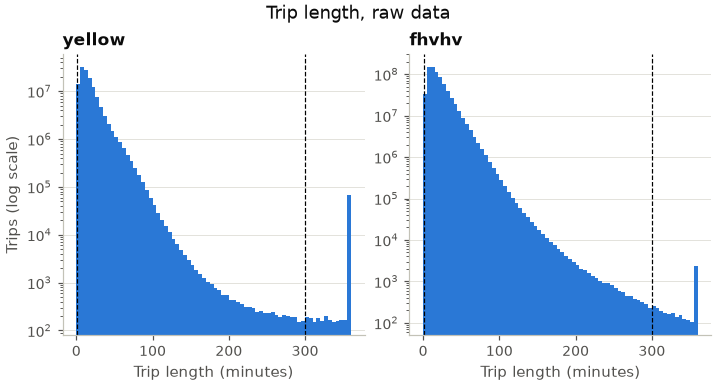

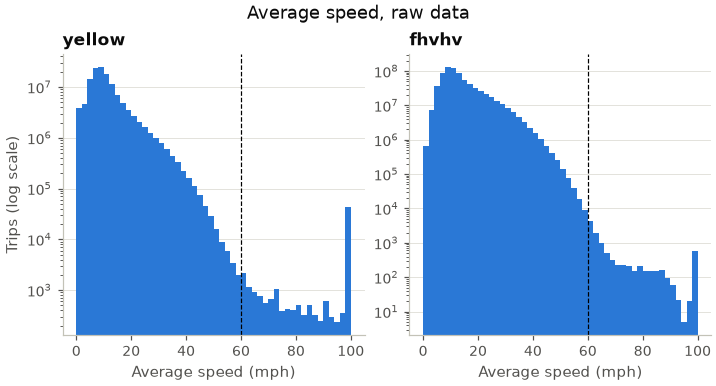

In [18]:
# Full-data histograms of trip length and average speed. Dashed lines are
# the cut-offs in clean.py.
minutes = {s: clean.histogram(raw[s].withColumn("trip_minutes",
                                                F.col("trip_seconds") / 60),
                              "trip_minutes", 0, 360, 5)
           for s in config.SERVICES}
plots.histograms(minutes, [clean.MIN_TRIP_MINUTES, clean.MAX_TRIP_MINUTES],
                 "Trip length (minutes)", "Trip length, raw data")
plt.show()

speeds = {s: clean.histogram(raw[s], "speed_mph", 0, 100, 2)
          for s in config.SERVICES}
plots.histograms(speeds, [clean.MAX_SPEED_MPH], "Average speed (mph)",
                 "Average speed, raw data")
plt.show()

**Cut-offs** (constants at the top of `scripts/clean.py`; the rows each one removes are in the step table in Section 3.7):

- **Trip length:** at least 1 minute and at most 5 hours. Past about 4 hours both histograms flatten into a thin tail of a few dozen trips per bin, which looks like meters left running, and the last bin holds every trip of 6 hours or more.
- **Distance:** at most 100 miles. The 99.9th percentile is about 30 miles for yellow and 50 miles for HVFHV.
- **Average speed:** at most 60 mph over the whole trip. The 99.9th percentile is under 50 mph for both services, and above 60 mph the histograms show only scattered trips, then a pile-up of impossible values in the last bin.
- **Money:** `fare_amount` (yellow) or `driver_pay` (HVFHV) at most $500. The 99.9th percentile is about $130–145 for both.

The cut-offs are wide on purpose: they only remove values that can't be real, so the summary medians don't depend on exactly where the line is.

### 3.6 Time bands

Share of trips in each pickup hour, on weekdays and weekends. The toll for cars has a peak rate on weekdays from 5am to 9pm (9am to 9pm on weekends) and a lower overnight rate. The CBD fee on taxi and rideshare trips doesn't change by hour (next cell).

yellow


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
fee,,,,,,,,,,,,,,,,,,,,,
-0.75,15911,11254,8242,6224,4646,3331,4950,7540,9925,14700,...,32443,33692,36925,37654,38366,35286,31998,30350,27847,21631
0.00,333517,190610,114817,92248,110523,151476,276675,494045,593165,606172,...,852320,900269,855041,893636,883194,752068,662423,639522,583451,480766
0.75,1190764,813867,545312,358598,245748,230627,477149,881568,1266105,1377870,...,1856164,1920147,2042944,2359860,2551640,2284248,2131699,2231170,2118868,1652550


fhvhv


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
fee,,,,,,,,,,,,,,,,,,,,,
0.0,5518062,3760695,2690651,2270923,2543696,3088805,4799558,7403127,8845548,7940813,...,8239709,8433710,8580791,9199584,9240938,8862317,8171900,7751468,7714571,7106356
1.5,3195752,2338105,1676952,1269337,1199463,1357903,2049439,2791983,3648358,3719924,...,3673699,3765220,4028169,4617163,5040390,4966181,4979446,5123961,4961330,4143092


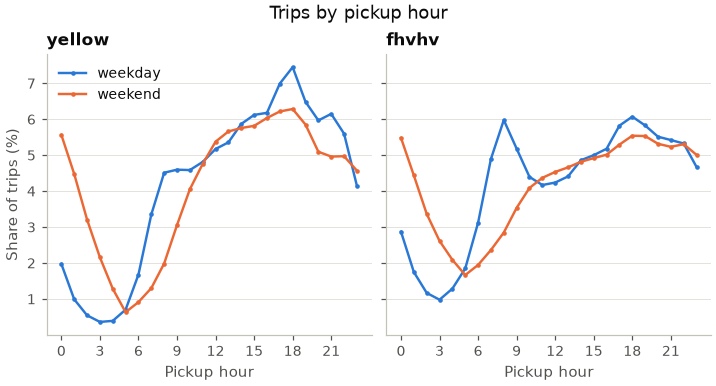

In [19]:
# CBD fee values on 2025 trips, by pickup hour
for service in config.SERVICES:
    print(service)
    display(clean.cbd_fee_by_hour(raw[service], service))  # noqa: F821

hourly = {s: clean.hourly_counts(raw[s], s) for s in config.SERVICES}
plots.hourly_shares(hourly, "Trips by pickup hour")
plt.show()

The fee is the same at every hour and takes only one value per service in all of 2025: **$0.75 on yellow trips** and **$1.50 on High Volume FHV trips** (negative values are reversals, and 0 is a trip that did not touch the zone). The fee itself therefore gives no reason to split the day. The bands follow the demand curve and the car toll's hours instead:

| Band | Pickup hours | Why |
|------|-------------|-----|
| `overnight` | 21:00–04:59 | The car toll's off-peak hours. Weekend nights are busy, weekday nights quiet. |
| `morning_peak` | 05:00–09:59 | The weekday toll peak starts at 5am, and weekday trips climb steeply to 9am |
| `midday` | 10:00–15:59 | Flat, steady demand on both day types |
| `evening` | 16:00–20:59 | The busiest hours, with the yellow $2.50 rush-hour surcharge (4–8pm); the toll peak ends at 9pm |

The same bands are used on every day of the week. The models compare each band with itself across dates, so weekend mornings being quieter doesn't matter.

### 3.7 Cleaning

Rules in the order they are applied. Each step keeps only the rows that pass it, and the rows × columns after every step come from one pass over the full data.

**Yellow:**

1. Keep only the columns we need (17 of 19–20).
2. Pickup date outside the month of the file.
3. Drop-off time before or equal to pickup time.
4. `payment_type` 3 (no charge), 4 (dispute) or 6 (voided trip), from the data dictionary: the fare wasn't collected or the trip itself is in doubt.
5. Zero or negative `fare_amount`, except Flex Fare trips (Section 3.3). Most negative fares are reversal rows that cancel a positive row.
6. `RatecodeID` 99 (null/unknown in the data dictionary). Flex Fare trips have a null `RatecodeID`, not 99, and are kept.
7. Zero or negative distance.
8.–11. The outlier cut-offs from Section 3.5: trip length, distance, speed, fare.
12. Pickup or drop-off in zone 264 (Unknown) or 265 (Outside of NYC), which have no location.

**High Volume FHV:** the same steps without 4–6, plus zero or negative `driver_pay` in their place.

In [20]:
steps = {}
for service in config.SERVICES:
    steps[service] = clean.step_shapes(raw[service], service,
                                       *raw_shapes[service])
    print(service)
    display(steps[service])  # noqa: F821

yellow


,step,reason,rows,columns,removed,removed_pct
0,raw,Raw files,128202548,19-20,0,0.000
1,keep_columns,Keep only the columns we need,128202548,17,0,0.000
2,pickup_in_file_month,Pickup date outside the month of the file (wro...,128201184,17,1364,0.001
3,dropoff_after_pickup,Drop-off time before or equal to pickup time,127625804,17,575380,0.449
4,charged_trip,"payment_type 3 (no charge), 4 (dispute) or 6 (...",124407631,17,3218173,2.510
5,positive_fare,Zero or negative fare (reversal rows). Flex Fa...,123959890,17,447741,0.349
6,known_ratecode,RatecodeID 99 (null/unknown). Flex Fare trips ...,122483608,17,1476282,1.152
7,positive_distance,Zero or negative distance,120019973,17,2463635,1.922
8,trip_length,Trip shorter than 1 minute or longer than 5 hours,119663843,17,356130,0.278
9,distance_cap,Distance over 100 miles,119659059,17,4784,0.004


fhvhv


,step,reason,rows,columns,removed,removed_pct
0,raw,Raw files,715550152,24-25,0,0.000
1,keep_columns,Keep only the columns we need,715550152,14,0,0.000
2,pickup_in_file_month,Pickup date outside the month of the file (wro...,715550152,14,0,0.000
3,dropoff_after_pickup,Drop-off time before or equal to pickup time,715519470,14,30682,0.004
4,positive_driver_pay,Zero or negative driver pay,714346062,14,1173408,0.164
5,positive_distance,Zero or negative distance,714260147,14,85915,0.012
6,trip_length,Trip shorter than 1 minute or longer than 5 hours,714218609,14,41538,0.006
7,distance_cap,Distance over 100 miles,714153724,14,64885,0.009
8,speed_cap,Average speed over 60 mph (impossible in NYC t...,714147401,14,6323,0.001
9,money_cap,driver_pay over $500,714147203,14,198,0.000


### 3.8 New columns

`clean.add_columns` adds:

- `trip_hours`: drop-off minus pickup, after turning the New York wall-clock times into real instants, so trips across a daylight saving change get the right length.
- `revenue` (yellow only): `fare_amount` plus the driver's part of `extra` (Section 3.4). It leaves out tips and every charge that goes to the city or MTA. Null when the fare is negative (the Vendor 2 Flex Fare problem) or no valid driver surcharge was found.
- `earnings`: `revenue` for yellow, `driver_pay` for HVFHV.
- `earnings_per_engaged_hour`: `earnings / trip_hours`. Null for shared HVFHV rides (`shared_match_flag` = Y), because the same driving time is split over more than one trip.
- `pickup_group`, `dropoff_group`: `cbd`, `ring` or `control` from the zone labels in Section 2.1.
- `trip_group`: `treated` if either end is in the CBD; `ring` if either end is in the ring and neither in the CBD; `control` if both ends are in control zones.
- `date`, `hour`, `time_band`, `day_of_week` (1 = Monday), and `after_toll` (pickup date on or after 5 January 2025).

The check below compares the Flex Fare share of yellow trips across trip groups, after cleaning.

In [21]:
trips = {s: clean.add_columns(clean.clean(raw[s], s), s, spark, zone_labels)
         for s in config.SERVICES}

print("Yellow: Flex Fare share of trips (%), by year and trip group")
display(clean.flex_fare_by_group(trips["yellow"]).round(1))  # noqa: F821

for service in config.SERVICES:
    print(f"{service}: trips with known earnings per engaged hour (%)")
    display(clean.earnings_coverage(trips[service]).round(1))  # noqa: F821

Yellow: Flex Fare share of trips (%), by year and trip group


trip_group,treated,ring,control
year,,,
2023,2.7,2.8,3.3
2024,9.9,7.6,12.6
2025,23.0,18.4,36.6


yellow: trips with known earnings per engaged hour (%)


trip_group,treated,ring,control
year,,,
2023,99.9,99.9,99.9
2024,99.6,99.7,99.6
2025,95.8,96.6,94.7


fhvhv: trips with known earnings per engaged hour (%)


trip_group,treated,ring,control
year,,,
2023,99.1,99.2,99.4
2024,98.3,98.2,98.5
2025,98.7,98.3,98.1


**What to look for:** if Flex Fare grows at about the same rate in every trip group, its growth can't bias the treated-versus-control comparison. On the full data it does **not**: the share of yellow trips booked as Flex Fare went from 2.7% (2023) to 9.9% (2024) to 23.0% (2025) for treated trips, but from 3.3% to 12.6% to **36.6%** for control trips, with ring trips lowest of all (2.8% to 18.4%). Flex Fare trips are real trips, so this is a real change in how yellow cabs outside the zone get their passengers, not a recording artefact — but it means the control group changed in a way the toll did not cause, which goes in Limitations.

It also leaves more control trips with unknown revenue in 2025, because of the negative Flex Fare fares in Section 3.3: earnings per engaged hour is known for 94.7% of control trips against 95.8% of treated trips that year. Both are high enough for the medians in the summary table to rest on nearly all trips, and coverage is above 98% for High Volume FHV in every group and year.

### 3.9 Summary table

One row per **service × pickup zone × drop-off group (cbd / ring / control) × date × time band**. The pickup zone and drop-off group together fix the trip group, so control trips are never mixed with trips that touch the ring. Columns:

- `trips`, `trips_with_earnings` (trips whose revenue or driver pay is known)
- `total_earnings` (revenue for yellow, driver pay for HVFHV) and `median_earnings` per trip
- `median_earnings_per_engaged_hour`, `engaged_hours` (total `trip_hours`)
- `median_speed_mph`
- `pickup_group`, `trip_group`, `after_toll`, `day_of_week`

Medians are computed on every trip in the group (`percentile_approx`, within 0.1% of the true rank). Every combination with no trips gets a row with 0 trips and 0 earnings (medians left empty), so zeros are not silently missing.

Spark builds the table one month at a time, because every row belongs to a single date. Each month is saved to `data/curated/summary_parts/` and reused on the next run; pass `overwrite=True` after changing a cleaning rule. The full table is saved to `data/curated/trip_summary.parquet`.

In [22]:
summary = clean.build_summary(spark, zone_labels, months)
print(f"Summary table: {summary.shape[0]:,} rows x {summary.shape[1]} "
      f"columns, saved to {clean.SUMMARY_FILE.name}")

# The trips in the summary must equal the rows left after cleaning
for service in config.SERVICES:
    in_summary = summary.loc[summary["service"] == service, "trips"].sum()
    assert in_summary == steps[service]["rows"].iloc[-1], service

print(f"Rows with 0 trips: {(summary['trips'] == 0).mean():.1%}")
(summary.groupby(["service", "trip_group",
                  summary["date"].dt.year.rename("year")])["trips"]
 .sum().unstack("year"))

yellow: 36 months summarised


fhvhv: 36 months summarised


Summary table: 6,917,952 rows x 16 columns, saved to trip_summary.parquet


Rows with 0 trips: 31.5%


year                     2023       2024       2025
service trip_group                                 
fhvhv   control     119049525  126502102  132636692
        ring         22207950   23495266   23965199
        treated      80569695   79338759   75807638
yellow  control       4114212    4446578    5916529
        ring          5062248    5382718    6013113
        treated      26786131   28542031   32176449

## 4. Join the external data onto the summary table

This finishes the external data work started in Section 2, but it comes after the cleaning, because it needs the summary table built in Section 3.9. Weather and the holiday flag join on the date, and subway riders join on the **pickup zone, date and time band**, so every row says how busy the subway was where and when the trip started. Zones with no station get 0 riders. No join may change the number of rows, which the assert inside `join_external` checks.

The result is saved as `data/curated/model_table.parquet`, the table the models in Section 6 are fitted to.

In [23]:
model_table, join_shapes = external.join_external(summary, subway,
                                                  weather)
display(join_shapes)  # noqa: F821
print(f"Saved to {external.MODEL_TABLE_FILE.name}")

# The joined-on columns, described over the rows that have trips
added = ["rain_mm", "snow_mm", "snow_depth_mm", "temp_max_c",
         "temp_min_c", "subway_riders", "subway_transfers"]
with_trips = model_table[model_table["trips"] > 0]
print(f"Rows on a public holiday: "
      f"{model_table['is_holiday'].mean():.1%}")
with_trips[added].describe().round(1)

,step,rows,columns
0,summary table (Step 3),6917952,16
1,+ daily weather (Central Park),6917952,21
2,+ public holiday flag,6917952,22
3,"+ subway riders (pickup zone, date, band)",6917952,24


Saved to model_table.parquet


Rows on a public holiday: 3.2%


,rain_mm,snow_mm,snow_depth_mm,temp_max_c,temp_min_c,subway_riders,subway_transfers
count,4736188.0,4736188.0,4736188.0,4736188.0,4736188.0,4736188.0,4736188.0
mean,3.3,0.7,1.6,18.0,10.2,4141.9,159.4
std,9.6,5.8,8.8,9.5,8.5,7759.6,483.7
min,0.0,0.0,0.0,-7.1,-16.0,0.0,0.0
25%,0.0,0.0,0.0,10.6,3.3,0.0,0.0
50%,0.0,0.0,0.0,18.3,10.0,1294.0,26.0
75%,1.3,0.0,0.0,26.1,17.8,4989.0,133.0
max,139.2,81.0,102.0,37.2,27.2,134163.0,11689.0


## 5. Explore the data and make maps

## 6. Models

Model 1: difference-in-differences regression. Model 2: LightGBM forecast of trips without the toll.